In [3]:
import torch
from torch import nn
from d2l import torch as d2l
import matplotlib.pyplot as plt
import pandas as pd
import torch

In [4]:
# Load dataset
changi_df = pd.read_csv('../../Data/Final/TT Split/changi_train_long.csv')

# Pivot to create a time series for each (x, y)
changi_pivot = changi_df.pivot(index=['x', 'y'], columns='Date', values='Value')

# Reset index to keep (x, y) as columns
changi_pivot = changi_pivot.reset_index()

# Convert time columns back into a NumPy array
time_series_data = changi_pivot.iloc[:, 2:].values  # Ignore first two columns (x, y)
locations = changi_pivot.iloc[:, :2].values  # Store (x, y) separately

# Standardization (Z-score normalization)
mean_LST = time_series_data.mean()
std_LST = time_series_data.std()
time_series_data = (time_series_data - mean_LST) / std_LST  # Normalize

# Convert to PyTorch tensor and add extra dimension for LST feature
X_train_tensor = torch.tensor(time_series_data, dtype=torch.float32).unsqueeze(-1)

# Check tensor shape
print(X_train_tensor.shape)  # Expected: (num_locations, sequence_length, 1)


torch.Size([5290, 124, 1])


In [5]:
import torch
import torch.nn as nn

class LSTMPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=3, output_size=1):
        super(LSTMPredictor, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)  # Fully connected layer

    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # LSTM output
        out = self.fc(lstm_out)  # Fully connected layer for final prediction
        return out

In [6]:
# Define input (X) and target (y)
X_train = X_train_tensor  # (num_locations, sequence_length, 1)
y_train = X_train_tensor[:, 1:, :]  # Shifted by 1 time step for prediction

In [7]:
import torch.optim as optim

# Define model, loss function, and optimizer
model = LSTMPredictor()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 100  # Adjust as needed
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    # Forward pass
    predictions = model(X_train)
    
    # Compute loss
    loss = criterion(predictions[:, :-1, :], y_train)  # Ignore last time step
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}/{num_epochs}, Loss: {loss.item():.4f}")

Epoch 0/100, Loss: 1.0137
Epoch 10/100, Loss: 0.9906
Epoch 20/100, Loss: 0.9582
Epoch 30/100, Loss: 0.9325
Epoch 40/100, Loss: 0.9101
Epoch 50/100, Loss: 0.9029
Epoch 60/100, Loss: 0.8986
Epoch 70/100, Loss: 0.8931
Epoch 80/100, Loss: 0.8844
Epoch 90/100, Loss: 0.8606


In [8]:
import pandas as pd
import numpy as np
import torch

model.eval()  # Set model to evaluation mode

with torch.no_grad():
    X_test_pred = model(X_train)  # Forecast next steps
    X_test_pred = X_test_pred[:, -12:, :]  # Extract last 12 bimonthly periods (2023-2024)

# Convert predictions to a NumPy array
X_test_pred_np = X_test_pred.squeeze().cpu().numpy()  # Shape: (num_locations, 12)

# **Denormalize predictions**
X_test_pred_np = (X_test_pred_np * std_LST) + mean_LST  # Convert back to original scale

# Define bimonthly periods
bimonthly_periods = [
    "Jan-Feb 2023", "Mar-Apr 2023", "May-Jun 2023", "Jul-Aug 2023", "Sep-Oct 2023", "Nov-Dec 2023",
    "Jan-Feb 2024", "Mar-Apr 2024", "May-Jun 2024", "Jul-Aug 2024", "Sep-Oct 2024", "Nov-Dec 2024"
]

# Create a long-format DataFrame
df_pred = pd.DataFrame({
    "x": np.repeat(locations[:, 0], len(bimonthly_periods)),  # Use stored locations
    "y": np.repeat(locations[:, 1], len(bimonthly_periods)),  
    "Date": bimonthly_periods * len(locations),
    "Predicted_LST": X_test_pred_np.flatten()  # Store denormalized values
})

df_pred.to_csv('changi_pred_long.csv', index=False)


In [ ]:
true_df = pd.read_csv("changi_pred_long.csv")  # Replace with actual filename
pred_df = pd.read_csv("../../Data/Final/TT Split/changi_test_long.csv")  # Replace with actual filename

# Inspect the first few rows to ensure they match
print(true_df.head())
print(pred_df.head())

merged_df = true_df.merge(pred_df, on=["x", "y", "Date"], suffixes=("_true", "_pred"))

# Check if the merge was successful
print(merged_df.head())

# Compute RMSE
rmse = np.sqrt(np.mean((merged_df["Predicted_LST"] - merged_df["Value"]) ** 2))
print(f"RMSE in °C: {rmse:.2f}")

            x         y          Date  Predicted_LST
0  103.964566  1.350459  Jan-Feb 2023      26.940535
1  103.964566  1.350459  Mar-Apr 2023      26.526170
2  103.964566  1.350459  May-Jun 2023      25.890913
3  103.964566  1.350459  Jul-Aug 2023      25.255728
4  103.964566  1.350459  Sep-Oct 2023      24.829025
            x         y          Date      Value
0  103.964566  1.350459  Jan-Feb 2023  19.300148
1  103.964566  1.351269  Jan-Feb 2023  19.300060
2  103.964566  1.352079  Jan-Feb 2023  19.299971
3  103.964566  1.352889  Jan-Feb 2023  19.299883
4  103.965377  1.348838  Jan-Feb 2023  19.300281
            x         y          Date  Predicted_LST      Value
0  103.964566  1.350459  Jan-Feb 2023      26.940535  19.300148
1  103.964566  1.350459  Mar-Apr 2023      26.526170  21.802744
2  103.964566  1.350459  May-Jun 2023      25.890913  23.389268
3  103.964566  1.350459  Jul-Aug 2023      25.255728  22.872917
4  103.964566  1.350459  Sep-Oct 2023      24.829025  27.238957
RMSE

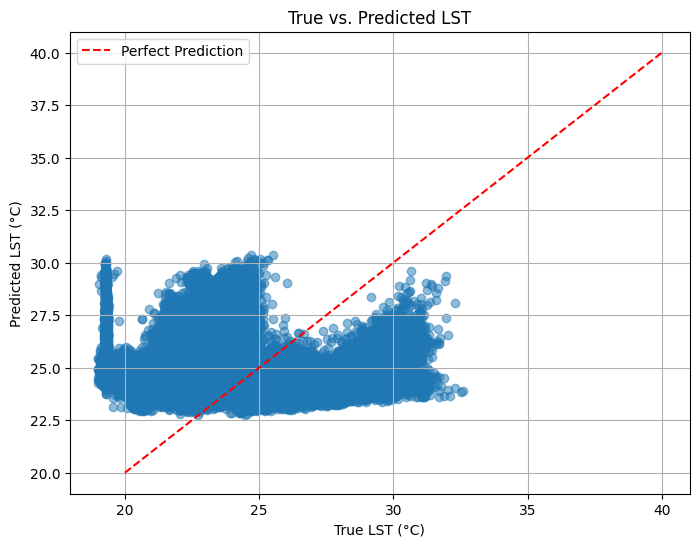

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(merged_df["Value"], merged_df["Predicted_LST"], alpha=0.5)
plt.plot([20, 40], [20, 40], color='red', linestyle='--', label="Perfect Prediction")  # Identity line
plt.xlabel("True LST (°C)")
plt.ylabel("Predicted LST (°C)")
plt.title("True vs. Predicted LST")
plt.legend()
plt.grid()
plt.show()
